<a href="https://www.kaggle.com/code/omborse771924/popular-movies-dataset-eda?scriptVersionId=332464539" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/okayyysidd/popular-movies-dataset/popular_shows_dataset.csv


## Loading Dataset


In [2]:
df = pd.read_csv('/kaggle/input/datasets/okayyysidd/popular-movies-dataset/popular_shows_dataset.csv')

In [3]:
df.head()

,title,year,revenue,imdb_id,tmdb_id,trakt_id
0,Hoppers,2026,29000000,tt26443616,1327819,1085761
1,Reminders of Him,2026,18000000,tt33714084,1367642,1116720
2,undertone,2026,9300000,tt35892608,1480387,1213506
3,Scream 7,2026,8400000,tt27047903,1159559,934134
4,GOAT,2026,4700000,tt27613895,1297842,1057839


In [4]:
df.tail()

,title,year,revenue,imdb_id,tmdb_id,trakt_id
995,The Bride!,2026,2100000,tt30851137,1159831,934595
996,Kiki's Delivery Service,1989,1700000,tt0097814,16859,10314
997,"""Wuthering Heights""",2026,1700000,tt32897959,1316092,1077273
998,Teenage Mutant Ninja Turtles II: The Secret of...,1991,1500000,tt0103060,1497,991
999,Crime 101,2026,1100000,tt32430579,1171145,944042


In [5]:
df.describe()

,year,revenue,tmdb_id,trakt_id
count,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03
mean,2018.800000,7.750000e+06,1.029867e+06,8.375175e+05
std,14.414152,8.705877e+06,5.195836e+05,4.246083e+05
min,1989.000000,1.100000e+06,1.497000e+03,9.910000e+02
25%,2026.000000,1.700000e+06,1.159559e+06,9.341340e+05
50%,2026.000000,3.400000e+06,1.234494e+06,1.000940e+06
75%,2026.000000,9.300000e+06,1.327819e+06,1.085761e+06
max,2026.000000,2.900000e+07,1.480387e+06,1.213506e+06


In [6]:
df.isnull()

,title,year,revenue,imdb_id,tmdb_id,trakt_id
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
995,False,False,False,False,False,False
996,False,False,False,False,False,False
997,False,False,False,False,False,False
998,False,False,False,False,False,False


In [7]:
df.isnull().sum()

title       0
year        0
revenue     0
imdb_id     0
tmdb_id     0
trakt_id    0
dtype: int64

In [8]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995     True
996     True
997     True
998     True
999     True
Length: 1000, dtype: bool

In [9]:
df.duplicated().sum()

np.int64(990)

In [10]:
df.columns

Index(['title', 'year', 'revenue', 'imdb_id', 'tmdb_id', 'trakt_id'], dtype='object')

## EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     1000 non-null   object
 1   year      1000 non-null   int64 
 2   revenue   1000 non-null   int64 
 3   imdb_id   1000 non-null   object
 4   tmdb_id   1000 non-null   int64 
 5   trakt_id  1000 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 47.0+ KB
None
              year       revenue       tmdb_id      trakt_id
count  1000.000000  1.000000e+03  1.000000e+03  1.000000e+03
mean   2018.800000  7.750000e+06  1.029867e+06  8.375175e+05
std      14.414152  8.705877e+06  5.195836e+05  4.246083e+05
min    1989.000000  1.100000e+06  1.497000e+03  9.910000e+02
25%    2026.000000  1.700000e+06  1.159559e+06  9.341340e+05
50%    2026.000000  3.400000e+06  1.234494e+06  1.000940e+06
75%    2026.000000  9.300000e+06  1.327819e+06  1.085761e+06
max    2026.000000  2.900000e+07  1.480387e+06 

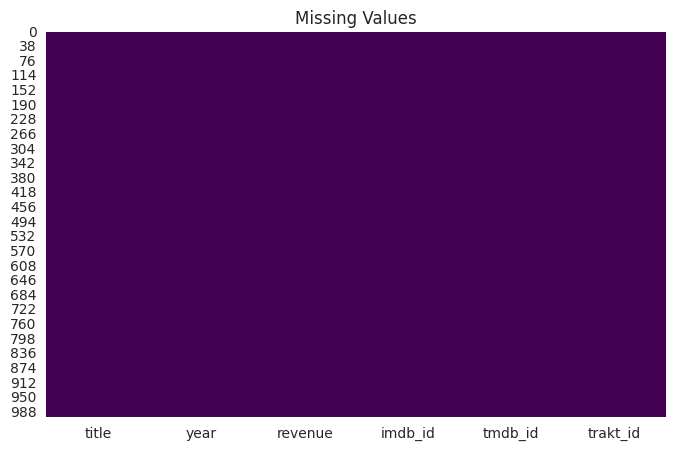

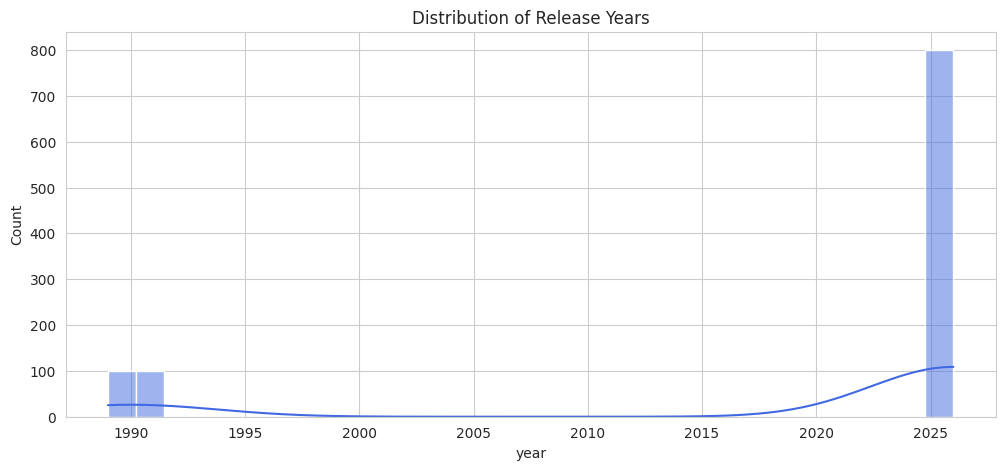

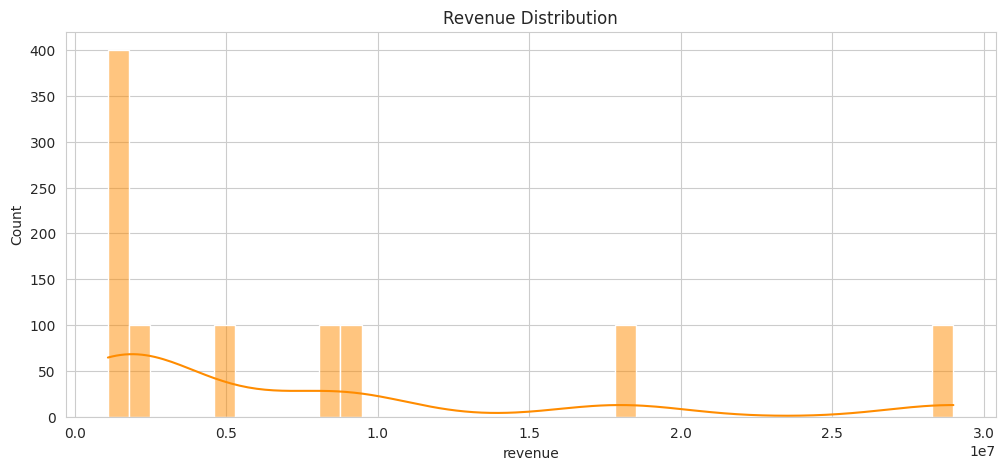

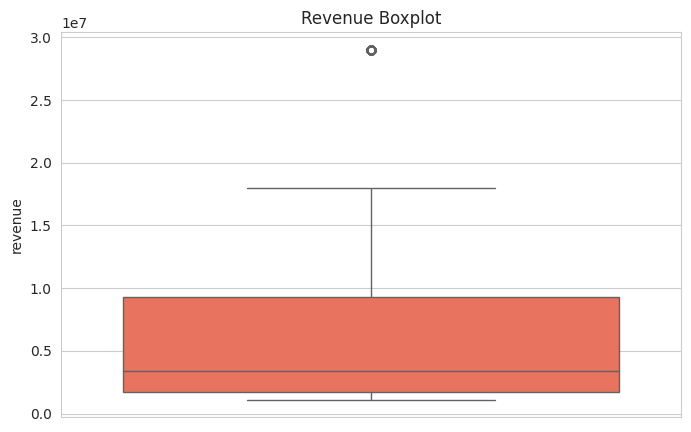

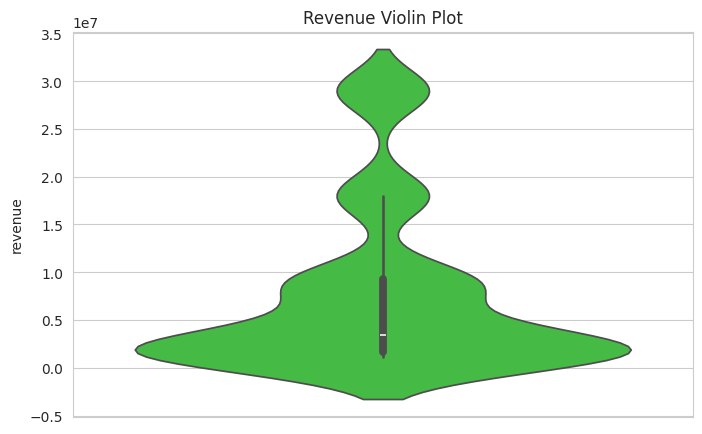

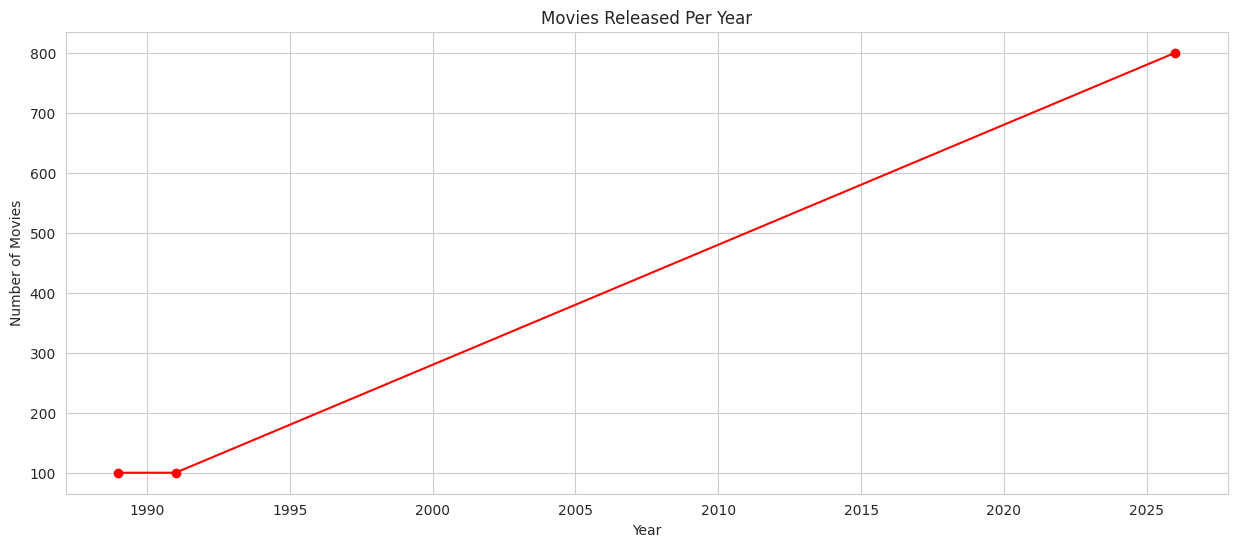

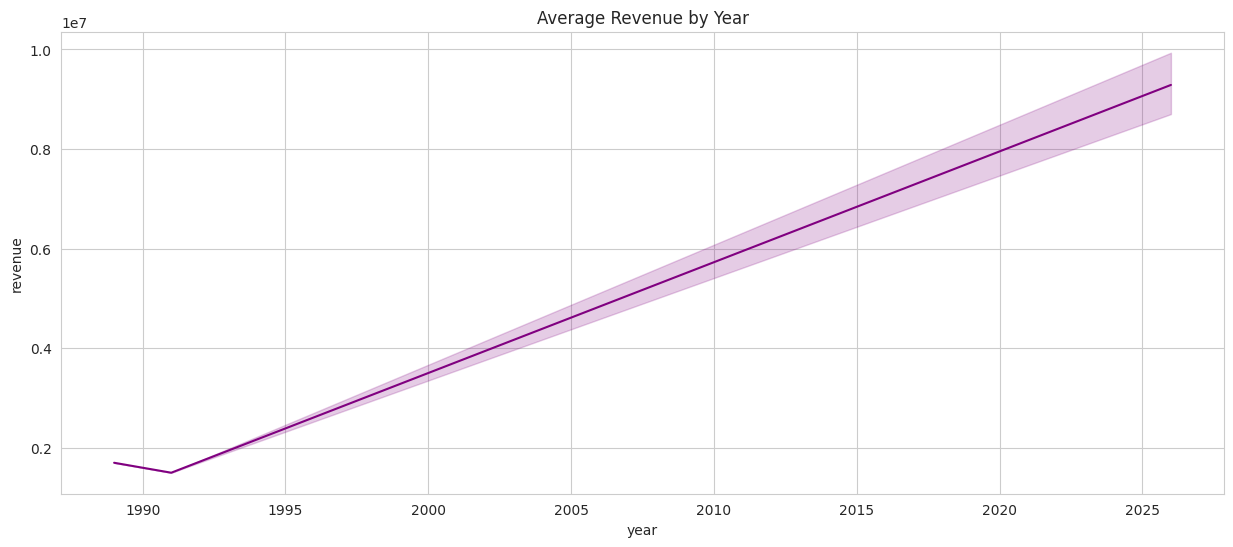

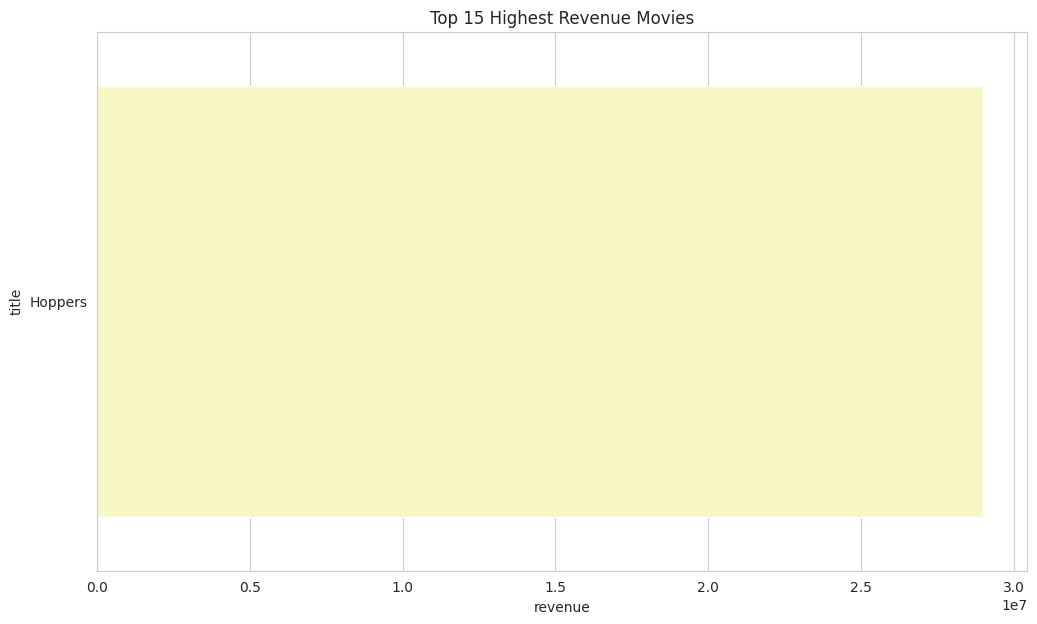

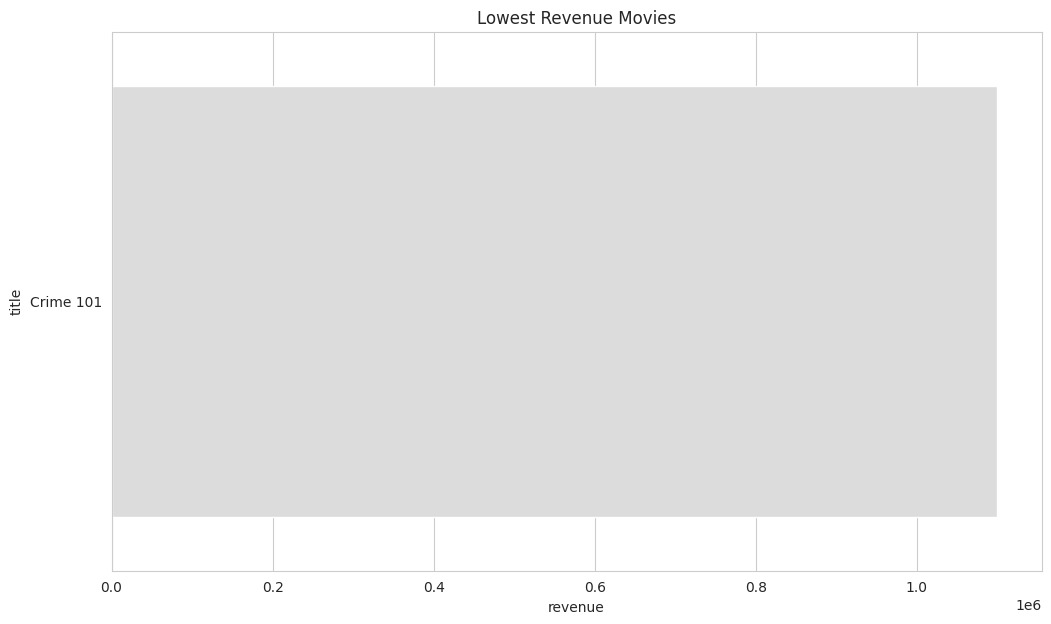

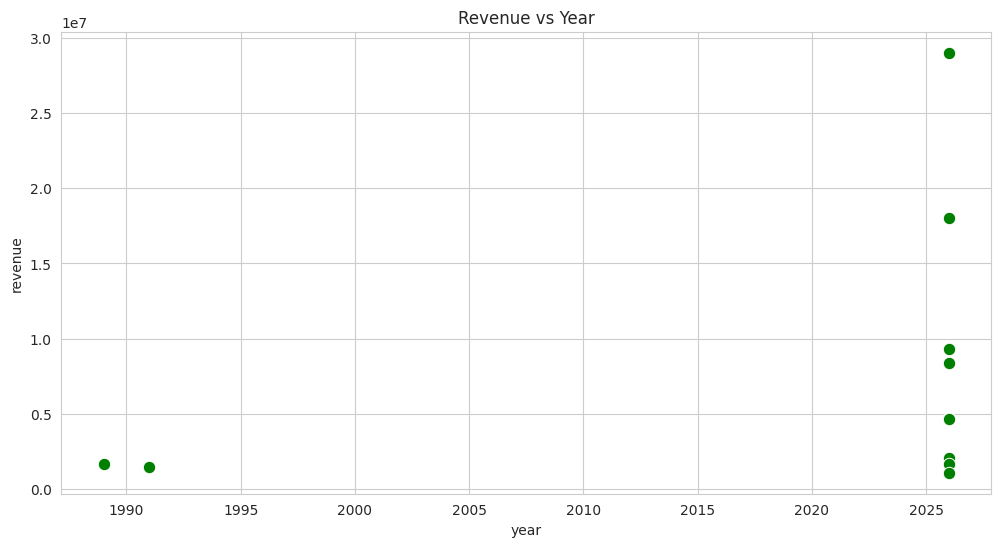

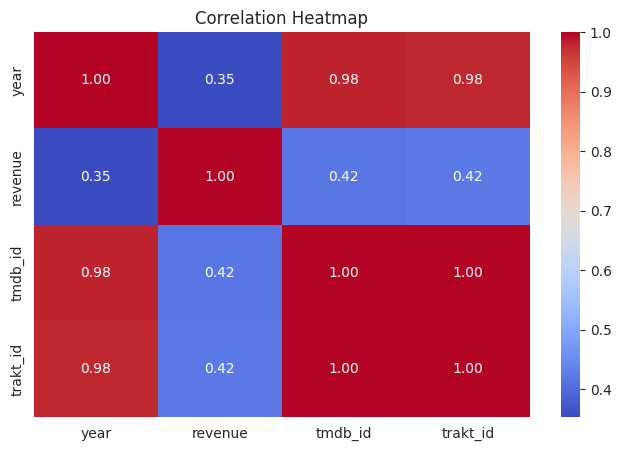

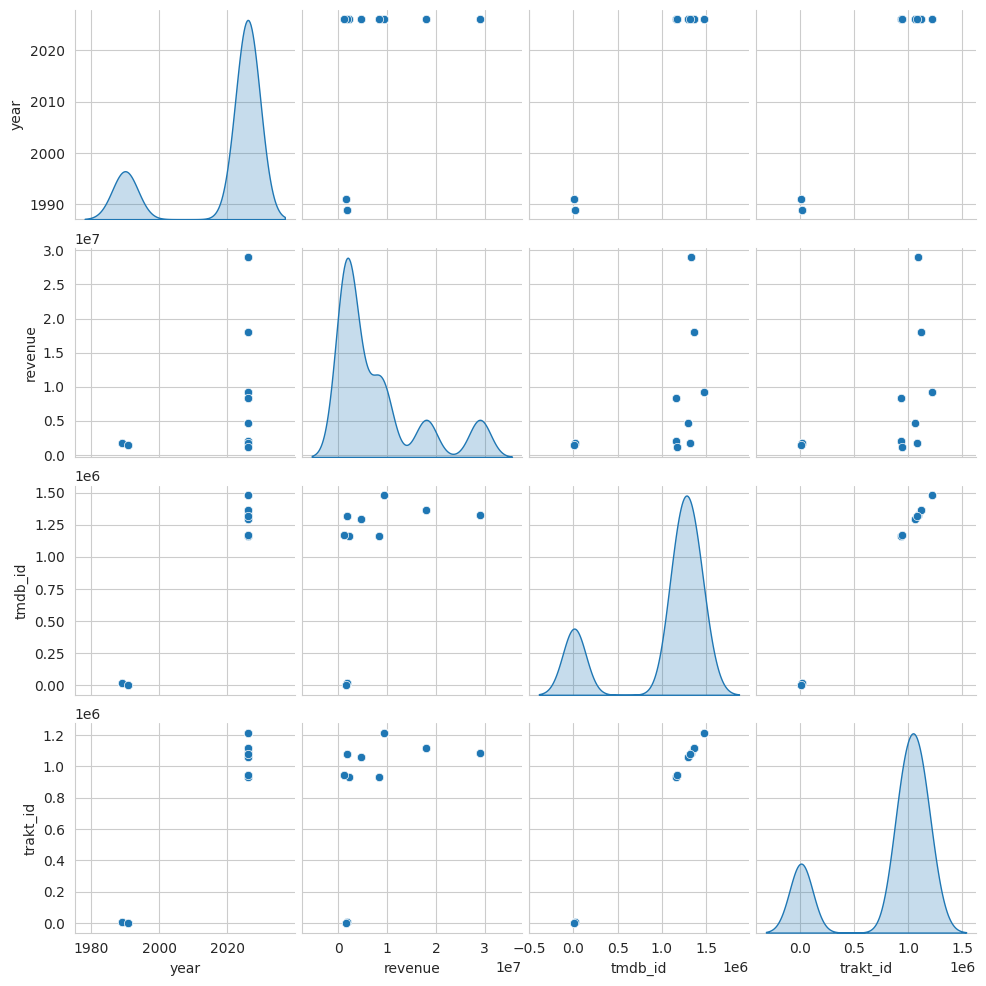

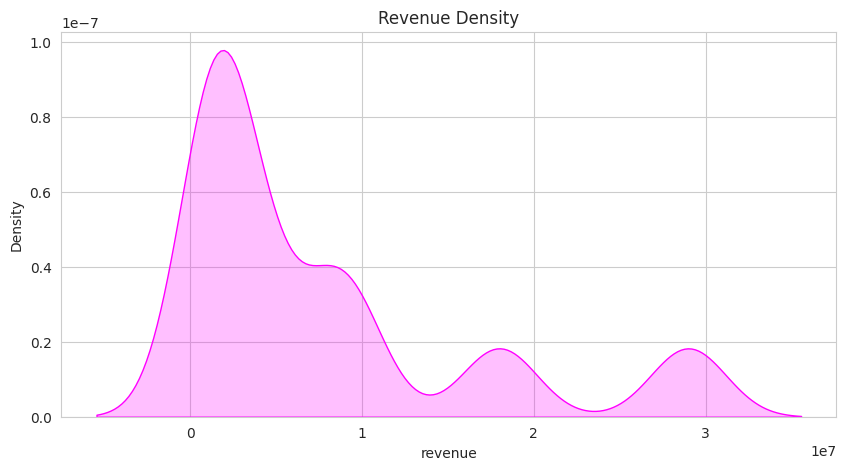

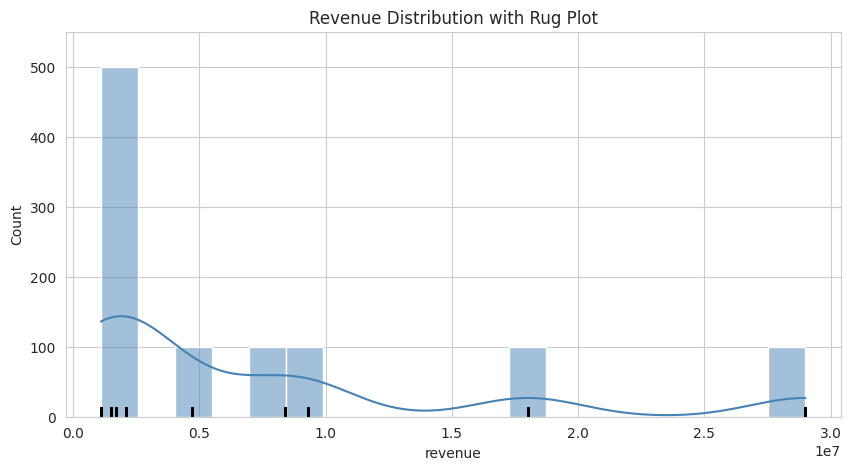

count    1.000000e+03
mean     7.750000e+06
std      8.705877e+06
min      1.100000e+06
25%      1.700000e+06
50%      3.400000e+06
75%      9.300000e+06
max      2.900000e+07
Name: revenue, dtype: float64
Duplicate Titles : 990
Unique IMDB IDs : 10
Unique TMDB IDs : 10
Unique TRAKT IDs : 10
Number of Revenue Outliers : 100


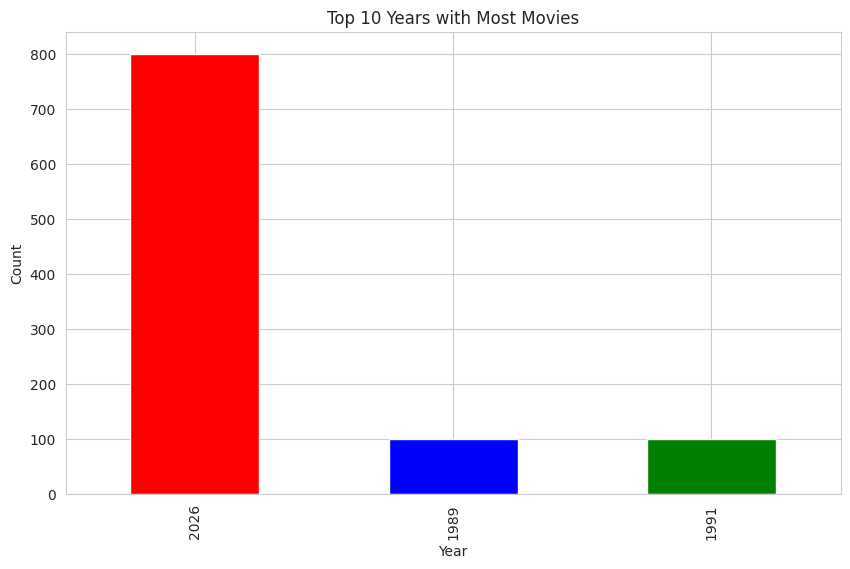

In [11]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(10,6)

# =====================================================
# 1. Dataset Information
# =====================================================

print(df.info())
print(df.describe())

# =====================================================
# 2. Missing Values
# =====================================================

plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values")
plt.show()

# =====================================================
# 3. Release Year Distribution
# =====================================================

plt.figure(figsize=(12,5))
sns.histplot(df["year"], bins=30, kde=True, color="royalblue")
plt.title("Distribution of Release Years")
plt.show()

# =====================================================
# 4. Revenue Distribution
# =====================================================

plt.figure(figsize=(12,5))
sns.histplot(df["revenue"], bins=40, kde=True, color="darkorange")
plt.title("Revenue Distribution")
plt.show()

# =====================================================
# 5. Revenue Boxplot
# =====================================================

plt.figure(figsize=(8,5))
sns.boxplot(y=df["revenue"], color="tomato")
plt.title("Revenue Boxplot")
plt.show()

# =====================================================
# 6. Revenue Violin Plot
# =====================================================

plt.figure(figsize=(8,5))
sns.violinplot(y=df["revenue"], color="limegreen")
plt.title("Revenue Violin Plot")
plt.show()

# =====================================================
# 7. Movies Released Per Year
# =====================================================

year_count = df["year"].value_counts().sort_index()

plt.figure(figsize=(15,6))
plt.plot(year_count.index, year_count.values,
         color="red", marker="o")
plt.title("Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.grid(True)
plt.show()

# =====================================================
# 8. Revenue by Year
# =====================================================

plt.figure(figsize=(15,6))
sns.lineplot(
    data=df,
    x="year",
    y="revenue",
    estimator="mean",
    color="purple"
)
plt.title("Average Revenue by Year")
plt.show()

# =====================================================
# 9. Top 15 Highest Revenue Movies
# =====================================================

top15 = df.nlargest(15,"revenue")

plt.figure(figsize=(12,7))
sns.barplot(
    data=top15,
    x="revenue",
    y="title",
    palette="Spectral"
)

plt.title("Top 15 Highest Revenue Movies")
plt.show()

# =====================================================
# 10. Lowest Revenue Movies
# =====================================================

bottom15 = df.nsmallest(15,"revenue")

plt.figure(figsize=(12,7))
sns.barplot(
    data=bottom15,
    x="revenue",
    y="title",
    palette="coolwarm"
)

plt.title("Lowest Revenue Movies")
plt.show()

# =====================================================
# 11. Revenue Scatter
# =====================================================

plt.figure(figsize=(12,6))
sns.scatterplot(
    data=df,
    x="year",
    y="revenue",
    color="green",
    s=80
)
plt.title("Revenue vs Year")
plt.show()

# =====================================================
# 12. Correlation Heatmap
# =====================================================

plt.figure(figsize=(8,5))

numeric=df.select_dtypes(include=np.number)

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# =====================================================
# 13. Pairplot
# =====================================================

sns.pairplot(
    numeric,
    diag_kind="kde"
)

plt.show()

# =====================================================
# 14. Revenue KDE
# =====================================================

plt.figure(figsize=(10,5))
sns.kdeplot(df["revenue"],
            fill=True,
            color="magenta")
plt.title("Revenue Density")
plt.show()

# =====================================================
# 15. Revenue Rug Plot
# =====================================================

plt.figure(figsize=(10,5))
sns.histplot(
    df["revenue"],
    kde=True,
    color="steelblue"
)

sns.rugplot(
    df["revenue"],
    color="black"
)

plt.title("Revenue Distribution with Rug Plot")
plt.show()

# =====================================================
# 16. Revenue Percentiles
# =====================================================

print(df["revenue"].describe())

# =====================================================
# 17. Duplicate Movie Titles
# =====================================================

duplicates=df["title"].duplicated().sum()

print("Duplicate Titles :",duplicates)

# =====================================================
# 18. Unique IDs
# =====================================================

print("Unique IMDB IDs :",df["imdb_id"].nunique())
print("Unique TMDB IDs :",df["tmdb_id"].nunique())
print("Unique TRAKT IDs :",df["trakt_id"].nunique())

# =====================================================
# 19. Revenue Outliers
# =====================================================

Q1=df["revenue"].quantile(0.25)
Q3=df["revenue"].quantile(0.75)

IQR=Q3-Q1

outliers=df[
    (df["revenue"]<Q1-1.5*IQR) |
    (df["revenue"]>Q3+1.5*IQR)
]

print("Number of Revenue Outliers :",len(outliers))

# =====================================================
# 20. Top 10 Release Years
# =====================================================

plt.figure(figsize=(10,6))

df["year"].value_counts().head(10).plot(
    kind="bar",
    color=["red","blue","green","orange","purple",
           "cyan","magenta","gold","brown","pink"]
)

plt.title("Top 10 Years with Most Movies")
plt.xlabel("Year")
plt.ylabel("Count")

plt.show()

## Features Engineering

In [12]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OrdinalEncoder,
    StandardScaler,
    LabelEncoder,
    label_binarize
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

# ============================================================
# CREATE TARGET COLUMN
# ============================================================

df["revenue_category"] = pd.qcut(
    df["revenue"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# ============================================================
# FEATURES & TARGET
# ============================================================

X = df.drop(
    columns=[
        "revenue",
        "revenue_category"
    ]
)

y = df["revenue_category"]

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

# ============================================================
# NUMERIC & CATEGORICAL COLUMNS
# ============================================================

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns

print("\nNumeric Features")
print(numeric_features)

print("\nCategorical Features")
print(categorical_features)

# ============================================================
# NUMERIC PIPELINE
# ============================================================

numeric_pipeline = Pipeline(
    [
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# ============================================================
# CATEGORICAL PIPELINE
# ============================================================

categorical_pipeline = Pipeline(
    [
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            )
        )
    ]
)

# ============================================================
# COLUMN TRANSFORMER
# ============================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            numeric_pipeline,
            numeric_features
        ),

        (
            "cat",
            categorical_pipeline,
            categorical_features
        )

    ]

)

print("\nPreprocessing Pipeline Created Successfully!")

Training Shape : (800, 5)
Testing Shape  : (200, 5)

Numeric Features
Index(['year', 'tmdb_id', 'trakt_id'], dtype='object')

Categorical Features
Index(['title', 'imdb_id'], dtype='object')

Preprocessing Pipeline Created Successfully!



Logistic Regression
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Classification Report

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        60
         Low       1.00      1.00      1.00        80
      Medium       1.00      1.00      1.00        60

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



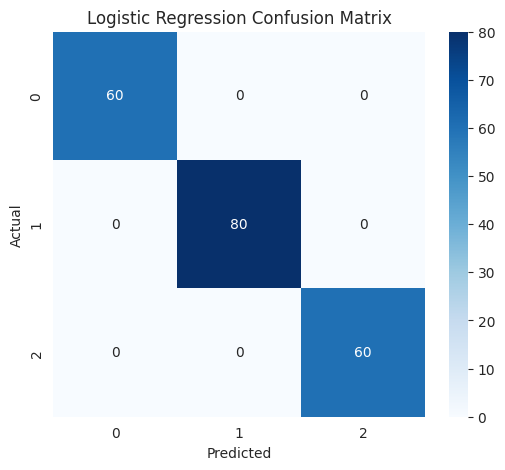


KNN
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Classification Report

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        60
         Low       1.00      1.00      1.00        80
      Medium       1.00      1.00      1.00        60

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



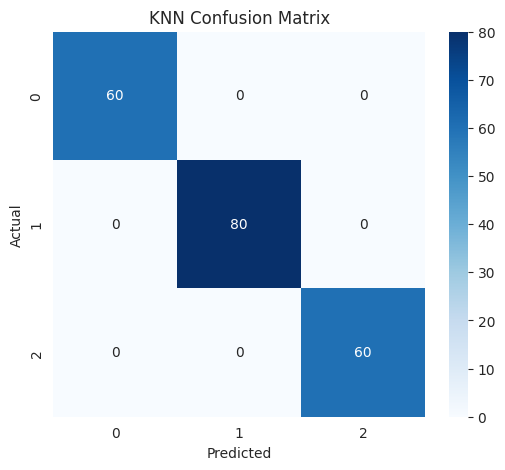


Decision Tree
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Classification Report

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        60
         Low       1.00      1.00      1.00        80
      Medium       1.00      1.00      1.00        60

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



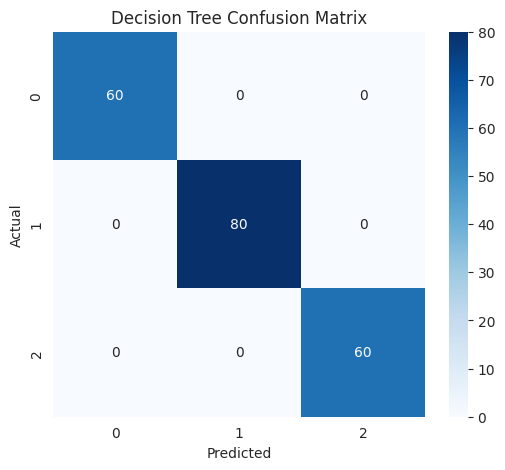



MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression       1.0        1.0     1.0       1.0
1                  KNN       1.0        1.0     1.0       1.0
2        Decision Tree       1.0        1.0     1.0       1.0


In [13]:
# ============================================================
# IMPORT ML MODELS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================================
# MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "KNN":
        KNeighborsClassifier(n_neighbors=5),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42)

}

results = []

# ============================================================
# TRAINING LOOP
# ============================================================

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Prediction
    y_pred = pipeline.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print("\n" + "="*70)
    print(name)
    print("="*70)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

# ============================================================
# COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("="*70)
print("MODEL COMPARISON")
print("="*70)

print(comparison)



Random Forest
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        60
         Low       1.00      1.00      1.00        80
      Medium       1.00      1.00      1.00        60

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



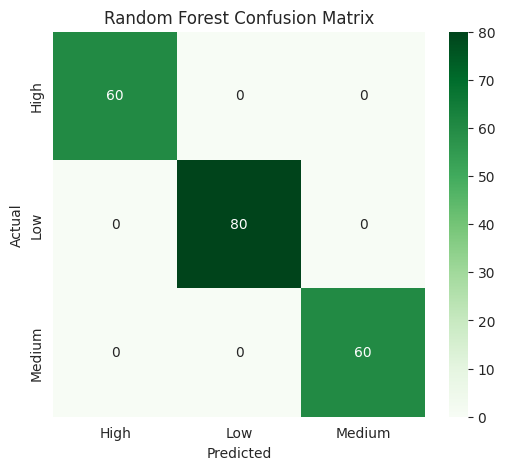

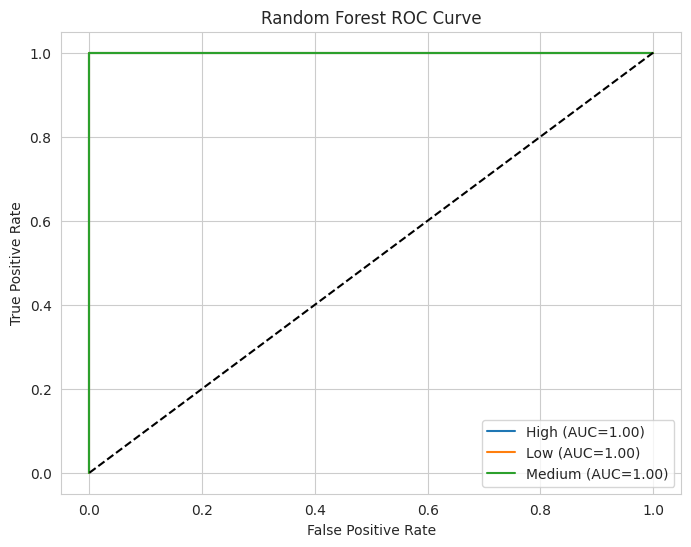



Support Vector Machine
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        60
         Low       1.00      1.00      1.00        80
      Medium       1.00      1.00      1.00        60

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



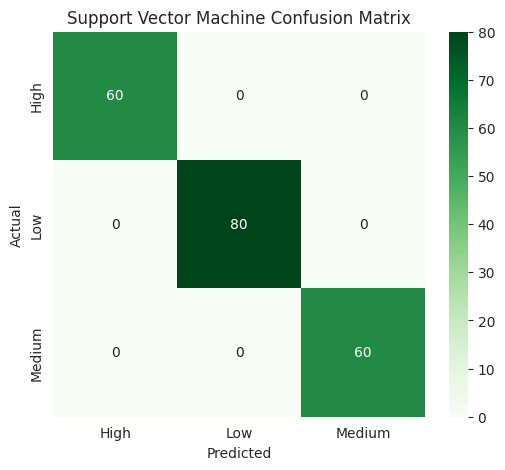

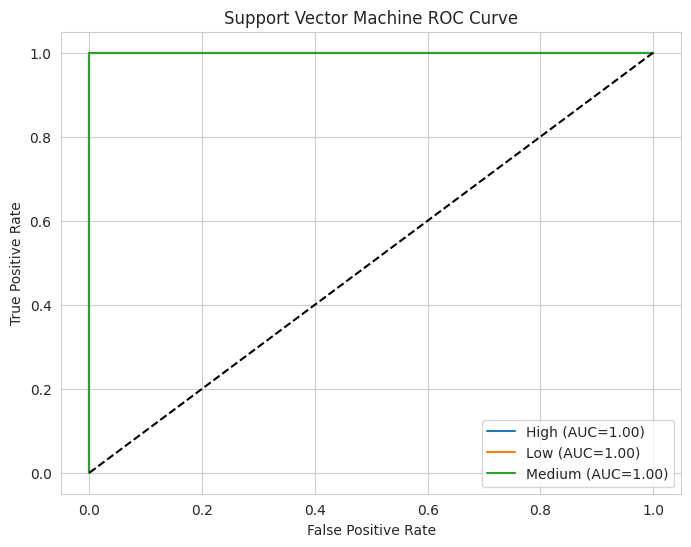



Gaussian Naive Bayes
Accuracy : 0.8
Precision: 0.85
Recall   : 0.8
F1 Score : 0.781

Classification Report

              precision    recall  f1-score   support

        High       0.75      1.00      0.86        60
         Low       1.00      0.50      0.67        80
      Medium       0.75      1.00      0.86        60

    accuracy                           0.80       200
   macro avg       0.83      0.83      0.79       200
weighted avg       0.85      0.80      0.78       200



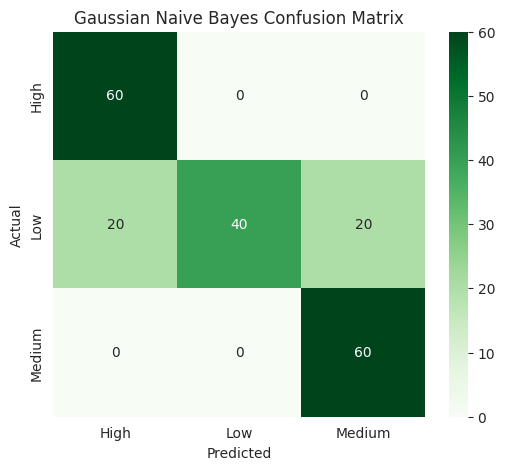

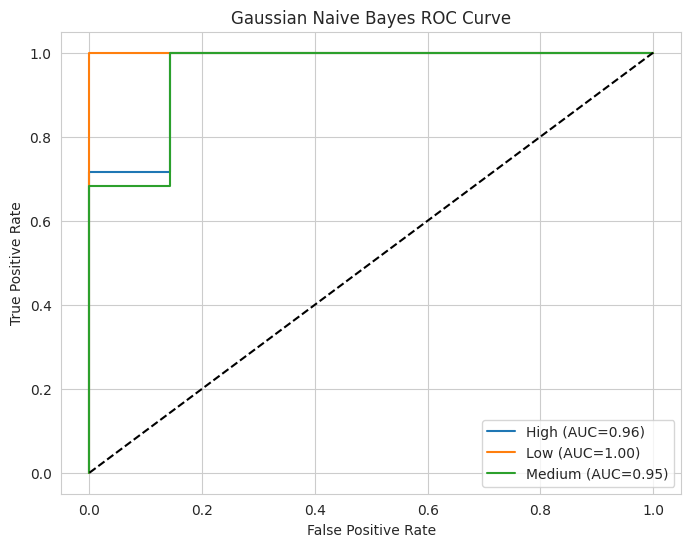



FINAL MODEL COMPARISON
                    Model  Accuracy  Precision  Recall  F1 Score
0           Random Forest       1.0       1.00     1.0  1.000000
1  Support Vector Machine       1.0       1.00     1.0  1.000000
2    Gaussian Naive Bayes       0.8       0.85     0.8  0.780952


In [14]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# ==========================================================
# ENCODE TARGET FOR ROC
# ==========================================================

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

n_classes = len(label_encoder.classes_)

# ==========================================================
# MODELS
# ==========================================================

models = {

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Support Vector Machine":
        SVC(
            probability=True,
            random_state=42
        ),

    "Gaussian Naive Bayes":
        GaussianNB()

}

results = []

# ==========================================================
# TRAIN MODELS
# ==========================================================

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train_encoded)

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test_encoded, y_pred)

    precision = precision_score(
        y_test_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test_encoded,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print("\n")
    print("="*70)
    print(name)
    print("="*70)

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))

    print("\nClassification Report\n")

    print(
        classification_report(
            y_test_encoded,
            y_pred,
            target_names=label_encoder.classes_
        )
    )

    # ======================================
    # Confusion Matrix
    # ======================================

    cm = confusion_matrix(
        y_test_encoded,
        y_pred
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        cmap="Greens",
        fmt="d",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.title(name + " Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    # ======================================
    # ROC Curve
    # ======================================

    y_prob = pipeline.predict_proba(X_test)

    y_test_bin = label_binarize(
        y_test_encoded,
        classes=np.arange(n_classes)
    )

    plt.figure(figsize=(8,6))

    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_prob[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"{label_encoder.classes_[i]} (AUC={roc_auc:.2f})"
        )

    plt.plot([0,1],[0,1],'k--')

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title(name + " ROC Curve")

    plt.legend()

    plt.show()

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

# ==========================================================
# FINAL COMPARISON
# ==========================================================

comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

print(comparison)

## Thanks.........Please Upvote...